# Criteo 1TB Click Logs 


Understand the data to justify the modelling choices choose the correct models to use

Only the training days are explored here, validation and training set will evaluate later 
Data downloaded with `scripts/download_data.py`.

In [1]:
# part 1 : import and setup


import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction import FeatureHasher
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
DATA_DIR = Path("../data/raw/data")
TRAIN_DAYS = ["2015-02-15", "2015-02-16"]

LABEL = "label"
INT_COLS = [f"integer_feature_{i}" for i in range(1, 14)]
CAT_COLS = [f"categorical_feature_{i}" for i in range(1, 27)]


def load_days(days: list[str]):
    """Load every parquet file of the given days and tag rows with their day."""
    frames = []
    for day in days:
        for path in sorted((DATA_DIR / f"day={day}").glob("*.parquet")):
            frames.append(pd.read_parquet(path).assign(day=day))
    return pd.concat(frames, ignore_index=True)


df = load_days(TRAIN_DAYS)
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head()

2,308,265 rows x 41 columns


,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26,day
0,0,NaN,84.0,NaN,31.0,12.0,0.0,0.0,1,8,...,f7389918,139221a3,8024f45f,0683bc6f,fa7eca6c,NaN,e716200f,30436bfc,2ccea557,2015-02-15
1,0,104.0,1045.0,30.0,NaN,1.0,0.0,0.0,1,9,...,6785af47,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,c91256e2,30436bfc,e1be5ef2,2015-02-15
2,0,6.0,145.0,10.0,NaN,4.0,0.0,0.0,0,12,...,a1eb1511,9512c20b,ef426d46,0683bc6f,6e86ac23,NaN,af97a0c1,30436bfc,b757e957,2015-02-15
3,0,40.0,360.0,7.0,NaN,9.0,0.0,0.0,312,0,...,b8170bba,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,245d9da7,30436bfc,e1be5ef2,2015-02-15
4,0,NaN,339.0,NaN,NaN,1.0,0.0,0.0,248,7,...,7232d217,9512c20b,14cde947,45f35b4b,f52bfc8b,NaN,edc6442f,ff654802,2ccea557,2015-02-15


In [3]:
df.dtypes.value_counts()

str        27
float64    11
int32       3
Name: count, dtype: int64

In [4]:
#part 2 : identify target dataset
target = df.groupby("day")[LABEL].agg(rows="size", clicks="sum", ctr="mean")
target.loc["total"] = [len(df), df[LABEL].sum(), df[LABEL].mean()]
target.astype({"rows": int, "clicks": int})

,rows,clicks,ctr
day,,,
2015-02-15,1529035,49044,0.032075
2015-02-16,779230,24803,0.031830
total,2308265,73847,0.031992


In [5]:
ctr = df[LABEL].mean()
baseline_logloss = log_loss(df[LABEL], np.full(len(df), ctr))
baseline_accuracy = 1 - ctr

print(f"CTR: {ctr:.4%} ")
print(f"Baseline log loss: {baseline_logloss:.5f}")
print(f"Baseline accuracy: {baseline_accuracy:.2%}")

CTR: 3.1992% 
Baseline log loss: 0.14160
Baseline accuracy: 96.80%


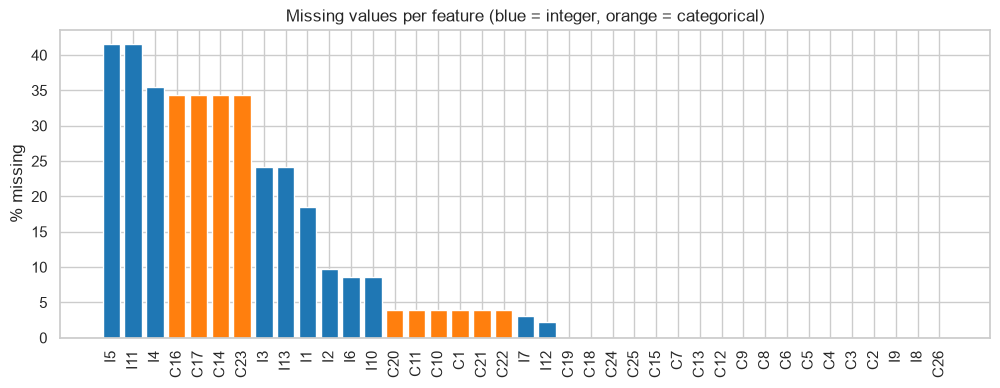

,null_rate
integer_feature_5,0.414964
integer_feature_11,0.414964
integer_feature_4,0.355440
categorical_feature_16,0.342948
categorical_feature_17,0.342948
categorical_feature_14,0.342948
categorical_feature_23,0.342948
integer_feature_3,0.241859
integer_feature_13,0.241859
integer_feature_1,0.185555


In [6]:
#part 3 missing values handling


#display count of missing values per features
FEATURES = INT_COLS + CAT_COLS
null_rate = df[FEATURES].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["tab:blue" if c in INT_COLS else "tab:orange" for c in null_rate.index]
ax.bar(range(len(null_rate)), null_rate.values * 100, color=colors)
ax.set_xticks(range(len(null_rate)))
ax.set_xticklabels([c.replace("integer_feature_", "I").replace("categorical_feature_", "C") for c in null_rate.index], rotation=90)
ax.set_ylabel("% missing")
ax.set_title("Missing values per feature (blue = integer, orange = categorical)")
plt.show()

null_rate[null_rate > 0].to_frame("null_rate")

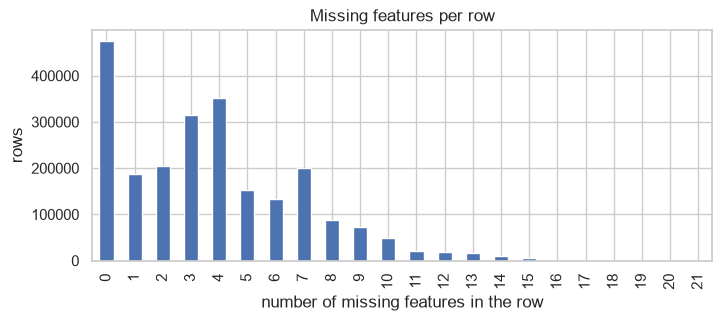

Mean missing features per row: 3.8/39
Rows with no missing value:    20.6%


In [7]:
#number of missing values per row
nulls_per_row = df[FEATURES].isna().sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 3))
nulls_per_row.value_counts().sort_index().plot.bar(ax=ax)
ax.set_xlabel("number of missing features in the row")
ax.set_ylabel("rows")
ax.set_title("Missing features per row")
plt.show()

print(f"Mean missing features per row: {nulls_per_row.mean():.1f}/{len(FEATURES)}")
print(f"Rows with no missing value:    {(nulls_per_row == 0).mean():.1%}")

In [8]:
#check whether missing values changes ctr

rows = []
for col in null_rate[(null_rate > 0.01) & (null_rate < 0.99)].index:
    is_null = df[col].isna()
    rows.append({
        "feature": col,
        "null_rate": is_null.mean(),
        "ctr_if_missing": df.loc[is_null, LABEL].mean(),
        "ctr_if_present": df.loc[~is_null, LABEL].mean(),
    })
missing_signal = pd.DataFrame(rows).set_index("feature")
missing_signal["ratio"] = missing_signal["ctr_if_missing"] / missing_signal["ctr_if_present"]
missing_signal.sort_values("ratio")

,null_rate,ctr_if_missing,ctr_if_present,ratio
feature,,,,
integer_feature_12,0.022339,0.014758,0.032386,0.455690
integer_feature_4,0.355440,0.019324,0.038979,0.495748
integer_feature_5,0.414964,0.023805,0.037799,0.629784
integer_feature_11,0.414964,0.023805,0.037799,0.629784
categorical_feature_22,0.039433,0.030388,0.032058,0.947907
categorical_feature_21,0.039433,0.030388,0.032058,0.947907
categorical_feature_1,0.039433,0.030388,0.032058,0.947907
categorical_feature_10,0.039433,0.030388,0.032058,0.947907
categorical_feature_11,0.039433,0.030388,0.032058,0.947907


In [9]:
#null rate in rows
null_masks = df[null_rate[null_rate > 0].index].isna()
groups = {}
for col in null_masks.columns:
    key = hash(null_masks[col].to_numpy().tobytes())
    groups.setdefault(key, []).append(col)

pd.DataFrame(
    [{"null_rate": null_rate[cols[0]], "features": ", ".join(cols)} for cols in groups.values() if len(cols) > 1]
).sort_values("null_rate", ascending=False)

,null_rate,features
0,0.414964,"integer_feature_5, integer_feature_11"
1,0.342948,"categorical_feature_16, categorical_feature_17..."
2,0.241859,"integer_feature_3, integer_feature_13"
3,0.085377,"integer_feature_6, integer_feature_10"
4,0.039433,"categorical_feature_20, categorical_feature_11..."


In [10]:
#part 4: integer feature exploration
int_stats = df[INT_COLS].describe(percentiles=[0.01, 0.5, 0.99]).T
int_stats["n_unique"] = df[INT_COLS].nunique()
int_stats["n_negative"] = (df[INT_COLS] < 0).sum()
int_stats

,count,mean,std,min,1%,50%,99%,max,n_unique,n_negative
integer_feature_1,1879954.0,36.160099,494.349148,1.0,1.0,8.0,306.00,65535.0,3708,0
integer_feature_2,2082936.0,432.690011,710.269597,1.0,1.0,196.0,3408.00,8000.0,7672,0
integer_feature_3,1749991.0,7.238196,10.780944,0.0,0.0,4.0,41.00,3480.0,345,0
integer_feature_4,1487816.0,134.463432,692.472907,0.0,0.0,34.0,1608.00,244016.0,6620,0
integer_feature_5,1350418.0,21.750927,74.589806,1.0,1.0,6.0,279.00,5115.0,1773,0
integer_feature_6,2111193.0,1.576453,6.660422,0.0,0.0,0.0,26.00,943.0,308,0
integer_feature_7,2238379.0,0.159161,2.133005,0.0,0.0,0.0,3.00,983.0,176,0
integer_feature_8,2308265.0,112.749743,386.868048,-1.0,-1.0,5.0,2247.00,21095.0,4750,144253
integer_feature_9,2308265.0,9.837399,18.355113,0.0,0.0,5.0,47.00,14019.0,178,0
integer_feature_10,2111193.0,0.281129,0.552274,0.0,0.0,0.0,2.00,9.0,10,0


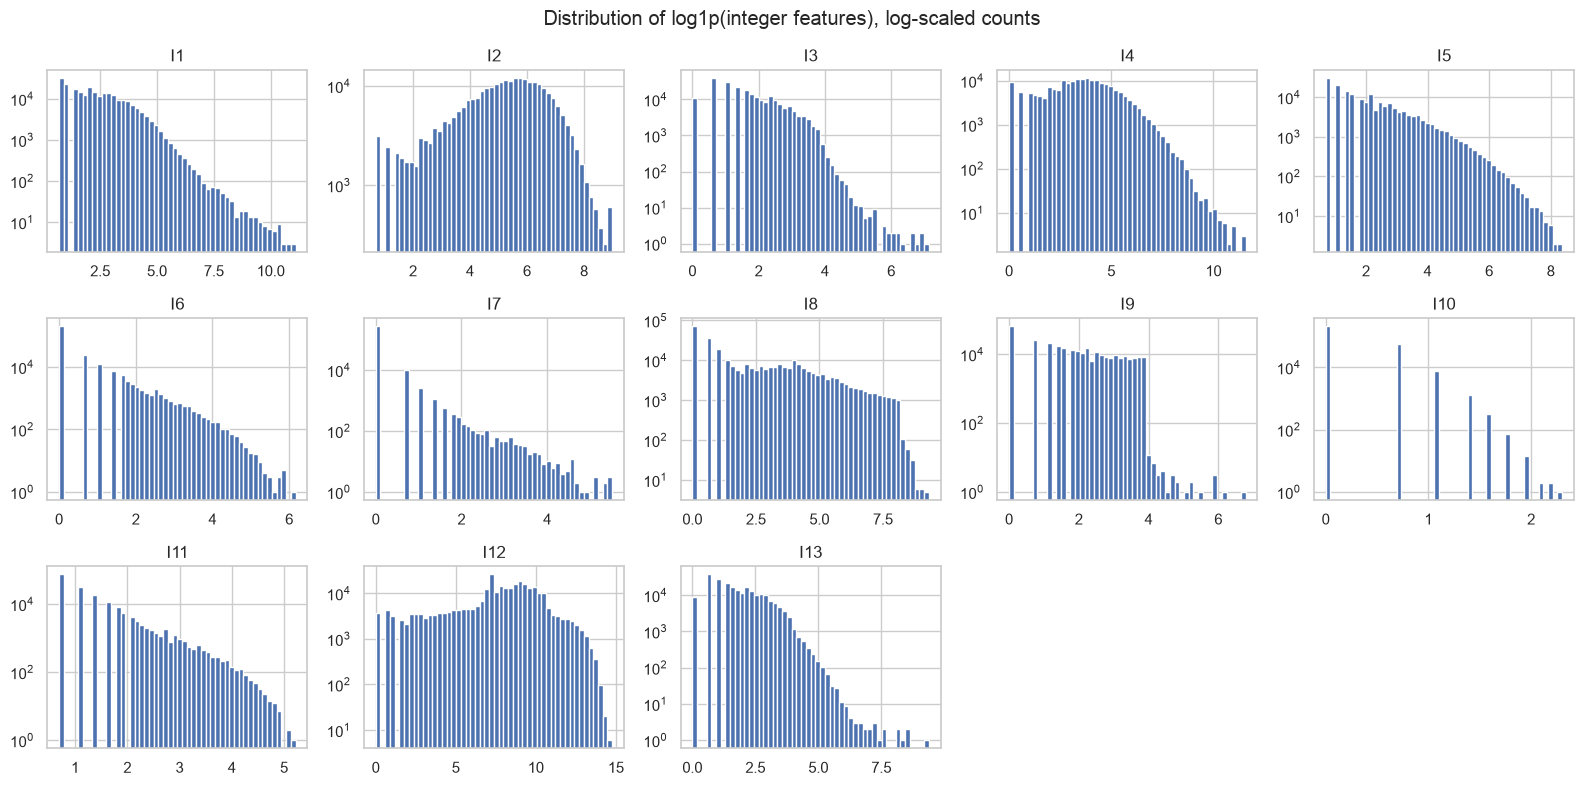

In [11]:
sample = df.sample(300_000, random_state=42)

fig, axes = plt.subplots(3, 5, figsize=(16, 8))
for ax, col in zip(axes.flat, INT_COLS):
    values = sample[col].dropna()
    ax.hist(np.log1p(values.clip(lower=0)), bins=50)
    ax.set_title(col.replace("integer_feature_", "I"))
    ax.set_yscale("log")
for ax in axes.flat[len(INT_COLS):]:
    ax.axis("off")
fig.suptitle("Distribution of log1p(integer features), log-scaled counts")
fig.tight_layout()
plt.show()

Signal check: CTR per decile of each feature (missing values shown as a separate point on the left).

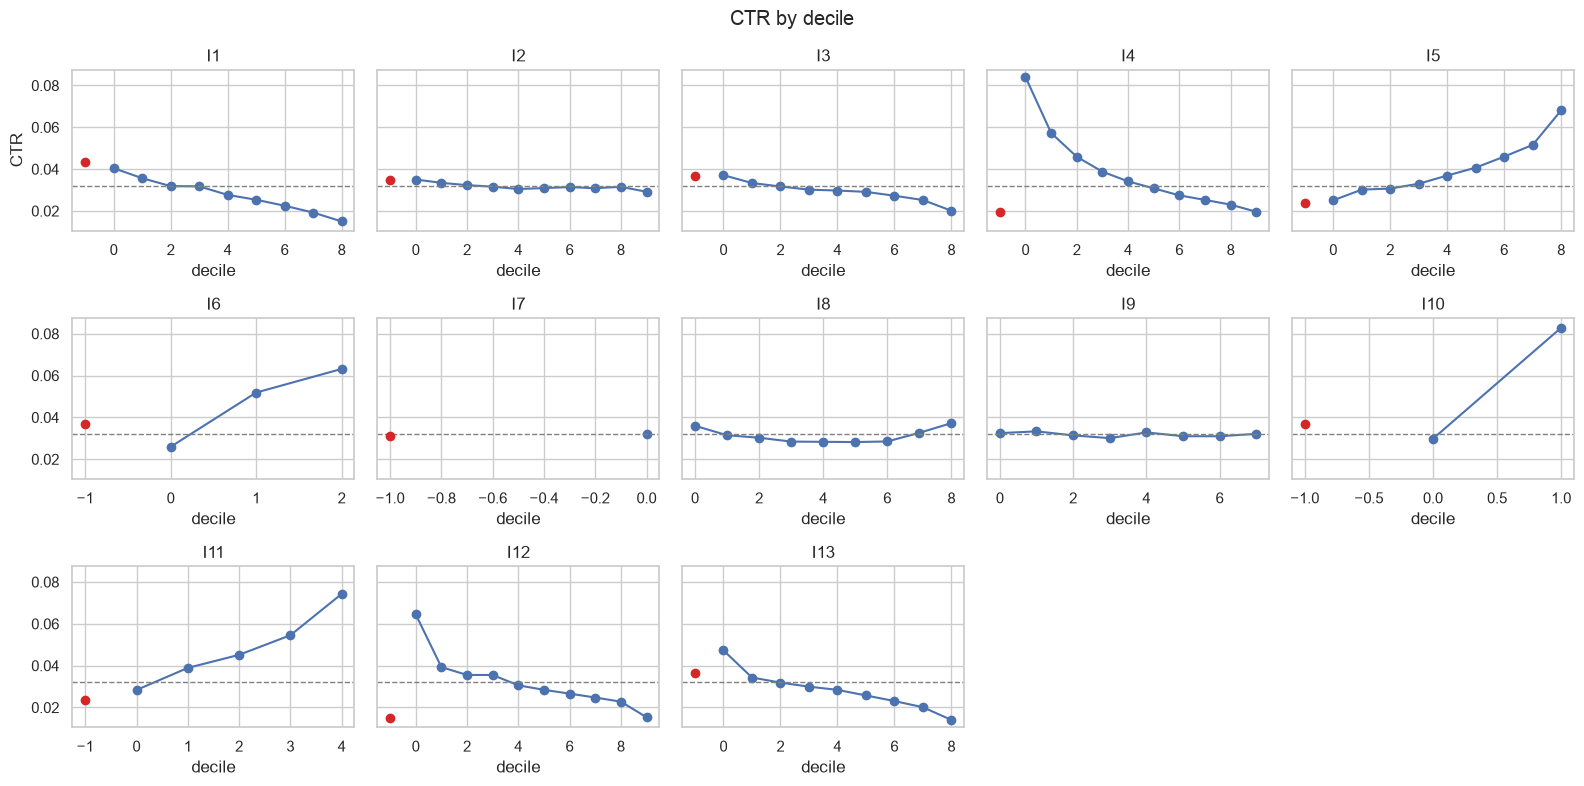

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(16, 8), sharey=True)
for ax, col in zip(axes.flat, INT_COLS):
    bins = pd.qcut(df[col], q=10, duplicates="drop")
    ctr_by_bin = df.groupby(bins, observed=True)[LABEL].mean()
    ax.plot(range(len(ctr_by_bin)), ctr_by_bin.values, marker="o")
    if df[col].isna().any():
        ax.scatter([-1], [df.loc[df[col].isna(), LABEL].mean()], color="tab:red", zorder=3)
    ax.axhline(ctr, color="grey", linestyle="--", linewidth=1)
    ax.set_title(col.replace("integer_feature_", "I"))
    ax.set_xlabel("decile")
for ax in axes.flat[len(INT_COLS):]:
    ax.axis("off")
axes[0, 0].set_ylabel("CTR")
fig.suptitle("CTR by decile")
fig.tight_layout()
plt.show()

In [13]:
spread = {}
for col in INT_COLS:
    ctr_by_bin = df.groupby(pd.qcut(df[col], q=10, duplicates="drop"), observed=True)[LABEL].mean()
    spread[col] = ctr_by_bin.max() / ctr_by_bin.min()
pd.Series(spread, name="CTR across deciles").sort_values(ascending=False).to_frame()

,CTR across deciles
integer_feature_4,4.286896
integer_feature_12,4.205930
integer_feature_13,3.370712
integer_feature_10,2.784337
integer_feature_5,2.716210
integer_feature_1,2.696907
integer_feature_11,2.619157
integer_feature_6,2.433155
integer_feature_3,1.846084
integer_feature_8,1.320643


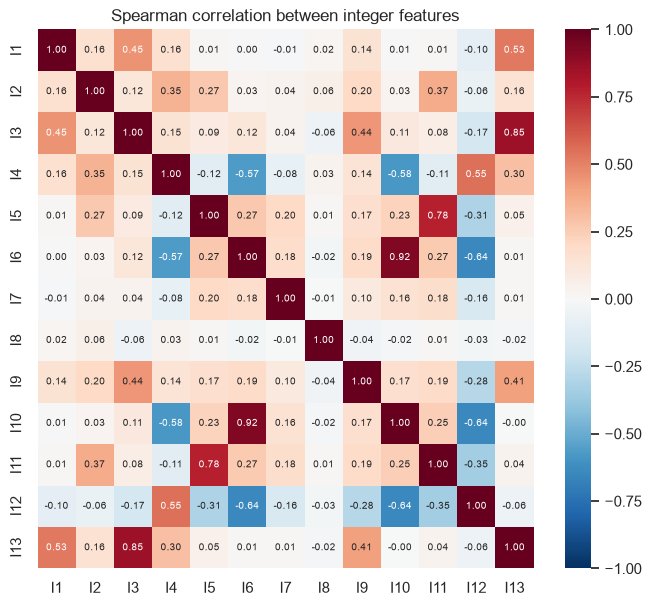

In [14]:
corr = df[INT_COLS].corr(method="spearman")
labels = [c.replace("integer_feature_", "I") for c in INT_COLS]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={"size": 7})
ax.set_title("Spearman correlation between integer features")
plt.show()

In [15]:
i8 = df["integer_feature_8"]
print(f"Values < 0 in integer_feature_8: {sorted(i8[i8 < 0].unique())}, {(i8 == -1).mean():.2%} of rows")
print(f"CTR when -1: {df.loc[i8 == -1, LABEL].mean():.4f}   CTR otherwise: {df.loc[i8 >= 0, LABEL].mean():.4f}")

i7 = df["integer_feature_7"]
print(f"\ninteger_feature_7 == 0: {(i7.dropna() == 0).mean():.2%} of non-null rows")
df.groupby(i7.clip(upper=3))[LABEL].agg(rows="size", ctr="mean")

Values < 0 in integer_feature_8: [np.int32(-1)], 6.25% of rows
CTR when -1: 0.0480   CTR otherwise: 0.0309

integer_feature_7 == 0: 94.34% of non-null rows


,rows,ctr
integer_feature_7,,
0.0,2111578,0.031374
1.0,79860,0.036414
2.0,20181,0.047074
3.0,26760,0.058558


**Takeaways**
- All integer features are **counts with very long tails** (e.g. `integer_feature_12`: median 2,964, max 3M; `integer_feature_4`: 99th percentile 1,608, max 244k). After `log1p` the distributions become well-behaved.
- `integer_feature_8` uses **`-1` as a missing-value sentinel** (6.25% of rows) and that value is informative (CTR 4.8% vs 3.1%).
- `integer_feature_7` is 0 in ~94% of non-null rows but the rare non-zero values carry signal (CTR rises from 3.1% to 5.9%).
- **Strongest univariate signal** (CTR ratio between best and worst decile): `integer_feature_4`, `integer_feature_12` (~4.2x), `integer_feature_13` (3.4x). Weakest: `integer_feature_2`, `integer_feature_9`, `integer_feature_7` (flat across deciles). Relations are mostly **monotonic** but non-linear (e.g. steep drop over the first deciles of `integer_feature_4`).
- Some strongly correlated pairs (Spearman): I6–I10 (0.92), I3–I13 (0.85), I5–I11 (0.78) — these are also the pairs that are missing together, so they likely describe the same entity. Not a problem for trees; mild redundancy for linear models.

→ **Decision**
- Trees: use raw values (invariant to monotonic transforms), treat `-1` in `integer_feature_8` as missing.
- Linear / neural models: replace `-1` by missing, then `log1p` (optionally clip at the 99.9th percentile), then the missing flag + fill from section 2. Standardise for the neural net.

In [16]:
#part 5: categorical features
rows = []
for col in CAT_COLS:
    counts = df[col].value_counts()  # excludes nulls
    rows.append({
        "feature": col,
        "n_unique": len(counts),
        "top_value_share": counts.iloc[0] / counts.sum(),
        "values_seen_once": (counts == 1).mean(),
        "rows_with_value_seen_lt_10": counts[counts < 10].sum() / counts.sum(),
    })
cat_stats = pd.DataFrame(rows).set_index("feature").sort_values("n_unique", ascending=False)
cat_stats

,n_unique,top_value_share,values_seen_once,rows_with_value_seen_lt_10
feature,,,,
categorical_feature_20,543367,0.243689,0.870509,0.299690
categorical_feature_1,499265,0.243689,0.858448,0.279838
categorical_feature_22,455601,0.243689,0.845196,0.260135
categorical_feature_10,374717,0.243689,0.814359,0.223232
categorical_feature_21,211807,0.243689,0.715472,0.142344
categorical_feature_11,77781,0.244353,0.538216,0.062095
categorical_feature_12,66565,0.210069,0.368347,0.054985
categorical_feature_23,60755,0.356251,0.475187,0.076143
categorical_feature_5,18689,0.206571,0.022527,0.022841


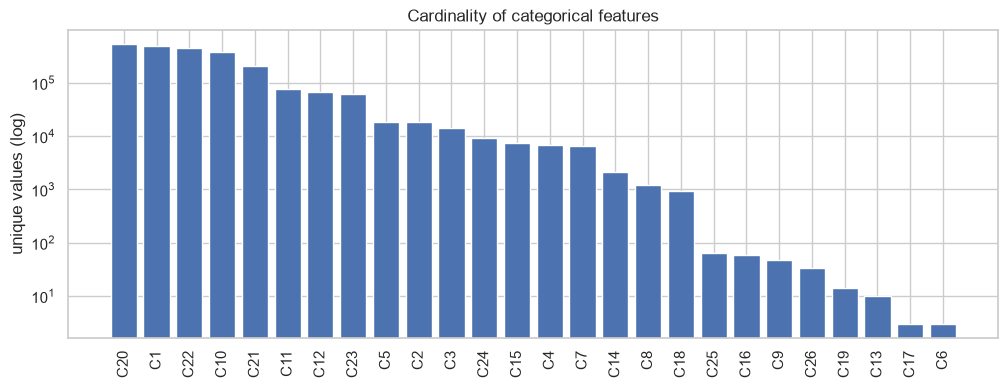

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(cat_stats)), cat_stats["n_unique"])
ax.set_xticks(range(len(cat_stats)))
ax.set_xticklabels([c.replace("categorical_feature_", "C") for c in cat_stats.index], rotation=90)
ax.set_yscale("log")
ax.set_ylabel("unique values (log)")
ax.set_title("Cardinality of categorical features")
plt.show()



Signal check: how much does each categorical feature tell about clicks on its own?
A smoothed target encoding is fitted on day 1 and evaluated on day 2 (so the score is not inflated by memorising rare values). Values unseen on day 1 get the global CTR.

In [18]:
day1 = df["day"] == TRAIN_DAYS[0]
day2 = ~day1
prior = df.loc[day1, LABEL].mean()
SMOOTHING = 20  # pseudo-count pulling rare values towards the global CTR

cat_auc = {}
for col in CAT_COLS:
    stats = df[day1].groupby(col, observed=True)[LABEL].agg(["sum", "count"])
    encoding = (stats["sum"] + SMOOTHING * prior) / (stats["count"] + SMOOTHING)
    encoded = df.loc[day2, col].astype(object).map(encoding).astype(float).fillna(prior)
    cat_auc[col] = roc_auc_score(df.loc[day2, LABEL], encoded)

cat_stats["target_encoding_auc"] = pd.Series(cat_auc)
cat_stats.sort_values("target_encoding_auc", ascending=False)[["n_unique", "target_encoding_auc"]]

,n_unique,target_encoding_auc
feature,,
categorical_feature_2,18351,0.646070
categorical_feature_3,14213,0.642580
categorical_feature_7,6424,0.636996
categorical_feature_24,9197,0.636693
categorical_feature_15,7338,0.634858
categorical_feature_21,211807,0.609970
categorical_feature_10,374717,0.607585
categorical_feature_11,77781,0.605142
categorical_feature_22,455601,0.604059


Choosing a frequency threshold for rare values: vocabulary size kept vs share of rows mapped to `OTHER`.

In [19]:
value_counts = {col: df[col].value_counts() for col in CAT_COLS}
rows = []
for min_count in (1, 5, 10, 20, 50, 100):
    kept = sum((vc >= min_count).sum() for vc in value_counts.values())
    other = np.mean([vc[vc < min_count].sum() / len(df) for vc in value_counts.values()])
    rows.append({"min_count": min_count, "vocabulary_size": kept, "avg_share_of_rows_to_OTHER": other})
pd.DataFrame(rows).set_index("min_count")

,vocabulary_size,avg_share_of_rows_to_OTHER
min_count,,
1,2375475,0.000000
5,231489,0.043334
10,140920,0.053260
20,84654,0.065813
50,46165,0.085523
100,28194,0.106511


# Part 2 — Model experiments

Models are trained on the training days (2015-02-15 and 2015-02-16) and compared on the **validation day** (2015-02-17), following the EDA decisions.
The test day (2015-02-18) stays untouched until the final model is chosen.

The model that wins here gets its preprocessing and training code moved to `src/` to be served by the API.

In [20]:
VAL_DAYS = ["2015-02-17"]

train = df  # the training days loaded in part 1
val = load_days(VAL_DAYS)
y_train = train[LABEL].to_numpy()
y_val = val[LABEL].to_numpy()

train_ctr = y_train.mean()
val_baseline_logloss = log_loss(y_val, np.full(len(y_val), train_ctr))
print(f"Validation: {len(val):,} rows, CTR {y_val.mean():.4%}")
print(f"Baseline log loss on validation (constant = train CTR): {val_baseline_logloss:.5f}")

Validation: 769,126 rows, CTR 3.2276%
Baseline log loss on validation (constant = train CTR): 0.14257


In [21]:
results = []


def evaluate(name: str, y_true: np.ndarray, y_pred: np.ndarray, train_seconds: float | None = None) -> pd.DataFrame:
    """Score a model on validation and add it to the results table."""
    ll = log_loss(y_true, y_pred)
    results.append({
        "model": name,
        "log_loss": ll,
        "vs_baseline": ll / val_baseline_logloss - 1,
        "roc_auc": roc_auc_score(y_true, y_pred),
        "mean_prediction": y_pred.mean(),
        "train_seconds": train_seconds,
    })
    return pd.DataFrame(results).set_index("model")


evaluate("baseline (train CTR)", y_val, np.full(len(y_val), train_ctr))

,log_loss,vs_baseline,roc_auc,mean_prediction,train_seconds
model,,,,,
baseline (train CTR),0.142567,0.0,0.5,0.031992,None


## Model 1 — Logistic regression with the hashing trick

Preprocessing, following the EDA decisions:
- **Integer features**: `-1` in `integer_feature_8` → missing, then `log1p`, missing filled with 0, plus one `is_missing` flag per feature, then standardised.
- **Categorical features**: each value becomes a token `"<feature>=<value>"` (`MISSING` for nulls), hashed into 2^20 buckets. No vocabulary to store, and values unseen during training are handled for free (they land in some bucket, never crash). The price is some hash collisions.

In [22]:
N_HASH_BUCKETS = 2**20
hasher = FeatureHasher(n_features=N_HASH_BUCKETS, input_type="string", alternate_sign=False)


def numeric_features(frame: pd.DataFrame) -> pd.DataFrame:
    X = frame[INT_COLS].astype(float)
    X.loc[X["integer_feature_8"] < 0, "integer_feature_8"] = np.nan
    is_missing = X.isna().astype(np.float32).add_suffix("_missing")
    return pd.concat([np.log1p(X).fillna(0), is_missing], axis=1)


def hashed_categoricals(frame: pd.DataFrame) -> sp.csr_matrix:
    tokens = [(col + "=") + frame[col].astype(object).fillna("MISSING").astype(str) for col in CAT_COLS]
    return hasher.transform(zip(*tokens))


start = time.time()
scaler = StandardScaler()
X_train_lr = sp.hstack([sp.csr_matrix(scaler.fit_transform(numeric_features(train))), hashed_categoricals(train)]).tocsr()
X_val_lr = sp.hstack([sp.csr_matrix(scaler.transform(numeric_features(val))), hashed_categoricals(val)]).tocsr()
print(f"Feature matrices built in {time.time() - start:.0f}s: train {X_train_lr.shape}, {X_train_lr.nnz / X_train_lr.shape[0]:.0f} non-zeros per row")

Feature matrices built in 51s: train (2308265, 1048602), 51 non-zeros per row


Regularisation strength `C` (smaller = stronger L2 penalty) chosen on the validation day:

In [23]:
lr_search = []
lr_models = {}
for C in (0.01, 0.05, 0.2):
    start = time.time()
    model = LogisticRegression(C=C, max_iter=300)
    model.fit(X_train_lr, y_train)
    seconds = time.time() - start
    p_val = model.predict_proba(X_val_lr)[:, 1]
    lr_models[C] = (model, p_val, seconds)
    lr_search.append({"C": C, "log_loss": log_loss(y_val, p_val), "roc_auc": roc_auc_score(y_val, p_val),
                      "iterations": model.n_iter_[0], "train_seconds": seconds})
pd.DataFrame(lr_search).set_index("C")

/Users/mamoune/Documents/perso/ctr_criteo/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,log_loss,roc_auc,iterations,train_seconds
C,,,,
0.01,0.128112,0.753175,87,26.657555
0.05,0.127463,0.757687,174,57.019018
0.20,0.128502,0.751924,300,91.826707


In [24]:
best_C = min(lr_models, key=lambda C: log_loss(y_val, lr_models[C][1]))
lr_model, p_val_lr, lr_seconds = lr_models[best_C]
evaluate(f"logistic regression (hashing, C={best_C})", y_val, p_val_lr, lr_seconds)

,log_loss,vs_baseline,roc_auc,mean_prediction,train_seconds
model,,,,,
baseline (train CTR),0.142567,0.000000,0.500000,0.031992,NaN
"logistic regression (hashing, C=0.05)",0.127463,-0.105941,0.757687,0.031886,57.019018


Calibration: when the model predicts *p*, is the observed CTR close to *p*? (bins with equal numbers of rows)

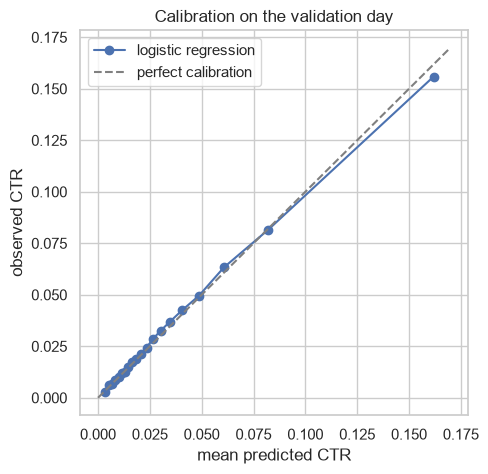

In [25]:
prob_true, prob_pred = calibration_curve(y_val, p_val_lr, n_bins=20, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(prob_pred, prob_true, marker="o", label="logistic regression")
lim = max(prob_pred.max(), prob_true.max()) * 1.05
ax.plot([0, lim], [0, lim], color="grey", linestyle="--", label="perfect calibration")
ax.set_xlabel("mean predicted CTR")
ax.set_ylabel("observed CTR")
ax.set_title("Calibration on the validation day")
ax.legend()
plt.show()

**Takeaways — logistic regression**
- Validation log loss **0.1275**, **−10.6% vs baseline** (0.1426), ROC-AUC **0.758**. Training takes ~1 minute on 2.3M rows × 1M hashed features.
- Best regularisation `C = 0.05`. Weaker regularisation (`C = 0.2`) overfits the rare hashed values (and does not converge within 300 iterations); stronger (`C = 0.01`) underfits.
- **Well calibrated**: the mean prediction (3.19%) matches the validation CTR (3.23%), and the calibration curve follows the diagonal — expected for logistic regression, which directly optimises log loss.
- Limitation: a linear model only learns one weight per value; it cannot combine features (e.g. "this ad *on* this publisher"). Tree models and neural networks capture these interactions → next models.